In [ ]:
# Global Oil and Gas Exposure Study
# 02: PopExposure Results Plotting

# This file plots results from Popexposure 
# Author: Lara Schwarz
# Last updated: September 2025

## Step 1: Load data used for plotting 
## Step 2: Combining and matching datasets
## Step 3: Figure 1 
## Step 4: Figure 2 
## Step 5: Figure 3 
## Step 6: Figure 4 
## Step 7: Figure S1 



In [12]:
## Importing libraries

import geopandas as gpd
import pandas as pd
import pathlib
import matplotlib.pyplot as plt
from thefuzz import process
import pandas as pd
import pathlib
import pandas as pd
import sys
import os
import rasterio
from rasterio.merge import merge
from rasterio.mask import mask
import geopandas as gpd
from rasterio.plot import show
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np
import fiona
import geopandas as gpd
from shapely.geometry import Polygon
import ee
import geemap
import matplotlib.cm as cm
import matplotlib.colors as colors
from shapely.geometry import box
import math
from shapely.geometry import Point
import glob
import seaborn as sns
import openpyxl
import subprocess
from pathlib import Path
from popexposure import PopEstimator
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

In [13]:
# Define base paths
repo = pathlib.Path.cwd().parent.parent
share_path = pathlib.Path("/Users/larasch/Library/CloudStorage/OneDrive-SharedLibraries-UW/casey_cohort - Documents/data")

# Define code path and add to sys.path
code_path = repo / "code"

# Define data paths
# location of the oil and gas data
oil_path = share_path / "environmental/oil_and_gas/raw_data/ogim.parquet"

# Define the paths
social_path = repo / "data/IHME_LSAE_admin2_LDIpc_2019_with_loc_id(in)_v2.csv"  

# location of the adminstrative boundary shapefile
countries_path = share_path / "geo_boundaries/processed_data/country_admin/country_geom_filtered.parquet"

# location of global shapefile
shapefile_path = repo / "data/OneDrive_1_12-11-2024/lbd_standard_admin_2.shp"

# location of the population data
pop_path = share_path / "social_including_census/raw_data/GHS_POP_E2020_GLOBE_R2023A_54009_100_V1_0/GHS_POP_E2020_GLOBE_R2023A_54009_100_V1_0.tif"

# Define the directory for the country-specific parquet files
country_dir = share_path / "geo_boundaries/processed_data/countries_ogd"

# Define the directory for the OGIM country-specific parquet files
ogim_dir = share_path / "environmental/oil_and_gas/raw_data/ogim_by_country"

# Define the directory for results
results_dir = repo / "results"


In [56]:
## Step 1: Load data used for plotting 

# Load EIA Excel data
excel_path =  repo / "data/EIA_global_ogd_production.xlsx"
eia_data = pd.read_excel(excel_path)
eia_data.rename(columns=lambda x: x.strip(), inplace=True)  # remove extra spaces in column names

# Load global oil data
oil = gpd.read_parquet(oil_path)

#  Load shapefile
global_shapefile = gpd.read_file(shapefile_path)
countries = global_shapefile.dissolve(by="ADM0_NAME", as_index=False)

## Load global country social data 
try:
    social_data = pd.read_csv(social_path, encoding='ISO-8859-1')  # or try encoding='utf-16'
    print("CSV loaded successfully with encoding ISO-8859-1.")
except UnicodeDecodeError:
    print("Error: Unable to decode CSV with the provided encoding.")

# merge the social and shapefile data
merged_shapefile_social = global_shapefile.merge(social_data, how='left', left_on='loc_id', right_on='loc_id')

# WBG classifications
wbg_path = repo / "data/WBG_classification.xlsx"
wbg_df = pd.read_excel(wbg_path)
wbg_df['Economy'] = wbg_df['Economy'].str.lower().str.replace(" ", "_")

# GRDI Data
GRDI_path = results_dir / "ogd_adm2_avg_GRDI.csv"
GRDI_data = pd.read_csv(GRDI_path)
GRDI_data = GRDI_data.rename(columns={
    'exposed_1km': 'GRDI_1km',
    'exposed_3km': 'GRDI_3km',
    'exposed_5km': 'GRDI_5km'
})
GRDI_data['country'] = GRDI_data['country'].str.lower().str.replace(" ", "_")

# Load country level exposure data
country_exp_path = results_dir / "ogd_country_pop_exposed.csv"
country_exposure = pd.read_csv(country_exp_path)

# Load ADM2 exposure data
exposed_adm2_path = results_dir / "ogd_adm2_pop_exposed.csv"
adm2_exposed = pd.read_csv(exposed_adm2_path)

CSV loaded successfully with encoding ISO-8859-1.


In [57]:
# Step 2: Combining and matching datasets

# Fuzzy match countries
# Define columns for matching
shapefile_country_col = 'ADM0_NAME'  # adjust to your shapefile column
eia_country_col = 'Country'             # adjust to your Excel column

# Make sure both columns are string type
countries[shapefile_country_col] = countries[shapefile_country_col].astype(str)
eia_data[eia_country_col] = eia_data[eia_country_col].astype(str)

eia_country_list = eia_data[eia_country_col].tolist()

# Create a dictionary mapping shapefile countries -> best match in EIA
mapping = {}
threshold = 90  # adjust as needed

for country in countries[shapefile_country_col].unique():
    if country == "Taiwan":
        mapping[country] = "Taiwan"  # force exact match
    else:
        match, score = process.extractOne(country, eia_country_list)
        if score >= threshold:
            mapping[country] = match
        else:
            mapping[country] = None  # no confident match
        
# Add a column to the shapefile with matched country names
countries['matched_country'] = countries[shapefile_country_col].map(mapping)

#  Merge using the matched names
# =========================
merged_gdf = countries.merge(
    eia_data,
    how='left',
    left_on='matched_country',
    right_on=eia_country_col
)

# Inspect merged data
print(merged_gdf.head())

               ADM0_NAME                                           geometry  \
0            Afghanistan  POLYGON ((64.48762 29.57178, 64.45548 29.56401...   
1  Akrotiri and Dhekelia  MULTIPOLYGON (((32.93319 34.57014, 32.93319 34...   
2                Albania  MULTIPOLYGON (((19.57042 40.17443, 19.57042 40...   
3                Algeria  MULTIPOLYGON (((1.32665 20.73298, 1.31754 20.7...   
4         American Samoa  MULTIPOLYGON (((-170.76947 -14.36564, -170.769...   

       geo_id  ad2_id  ad0_parent  ad1_parent  ADM2_CODE   ADM2_NAME  \
0  10007002.0      10           2           7   10007002  Qala-e-Kah   
1   1001246.0       1         246           1    1001246    Akrotiri   
2   1001006.0       1           6           1    1001006     Beratit   
3   1001065.0       1          65           1    1001065       Adrar   
4   1001011.0       1          11           1    1001011       Ituau   

   ADM1_CODE ADM1_NAME  ADM0_CODE  loc_id  matched_country          Country  \
0       7002 

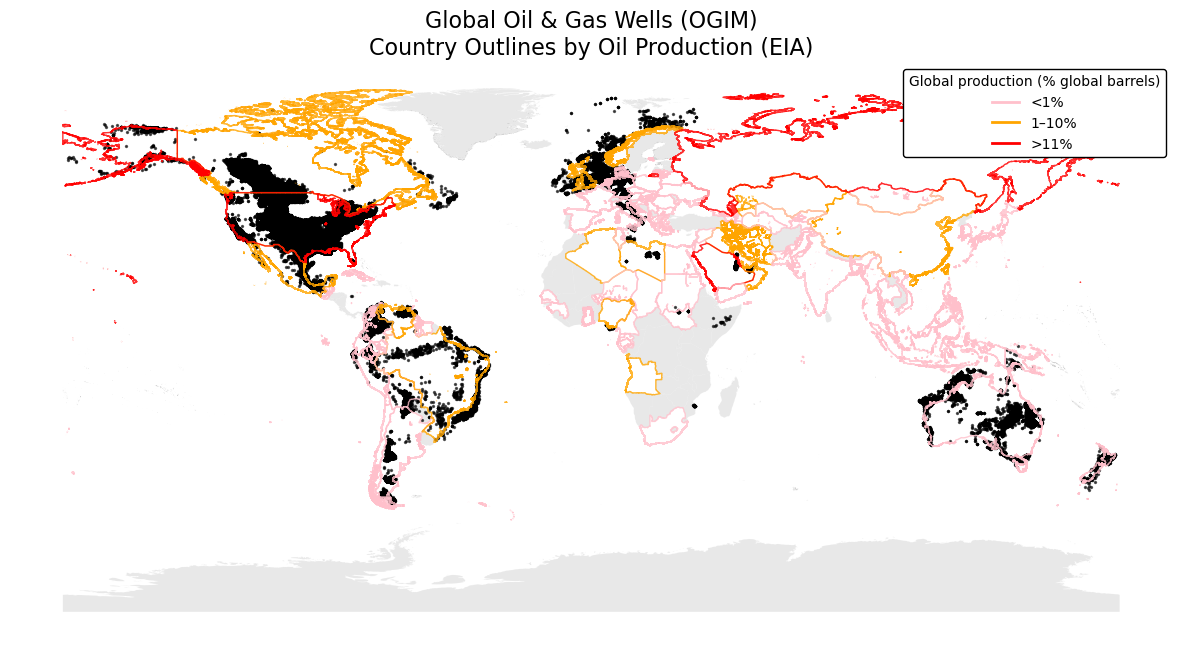

In [ ]:
## Step 3: Figure 1 

# Make sure both GeoDataFrames use the same CRS
merged_gdf = merged_gdf.to_crs(epsg=4326)
oil = oil.to_crs(merged_gdf.crs)

# Separate countries with numeric Percent_global and those with NaN
gdf_numeric = merged_gdf[merged_gdf['Percent_global'].notna()]
gdf_na = merged_gdf[merged_gdf['Percent_global'].isna()]

# Define color categories
def categorize_color(percent):
    if percent < 1:
        return "pink"
    elif 1 <= percent <= 10:
        return "orange"
    else:  # percent > 11
        return "red"

# Assign outline color based on Percent_global
gdf_numeric = gdf_numeric.copy()  # avoid SettingWithCopyWarning
gdf_numeric["outline_color"] = gdf_numeric["Percent_global"].apply(categorize_color)

# --- Plot ---
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Plot countries with NaN as light gray fill, no outline
gdf_na.plot(ax=ax, color="lightgray", edgecolor="none", alpha=0.5)

# Plot numeric countries outlines with category colors
gdf_numeric.boundary.plot(
    ax=ax,
    linewidth=1,
    edgecolor=gdf_numeric["outline_color"],
    alpha=0.8
)

# Overlay oil wells as points
oil.plot(ax=ax, color="black", markersize=2, alpha=0.6)

# Legend (color-coded instead of thickness)
legend_lines = [
    Line2D([0], [0], color="pink", lw=2),
    Line2D([0], [0], color="orange", lw=2),
    Line2D([0], [0], color="red", lw=2)
]
legend_labels = ["<1%", "1–10%", ">11%"]

legend = ax.legend(
    legend_lines,
    legend_labels,
    title="Global production (% global barrels)",
    loc="upper right",
    frameon=True,
    facecolor="white",  
    edgecolor="black",   
    framealpha=1         # solid background
)

#ax.legend(legend_lines, legend_labels, title="Global production (% global barrels)", loc="upper right")

plt.title("Global Oil & Gas Wells (OGIM)\nCountry Outlines by Oil Production (EIA)", fontsize=16)
plt.axis("off")
plt.show()

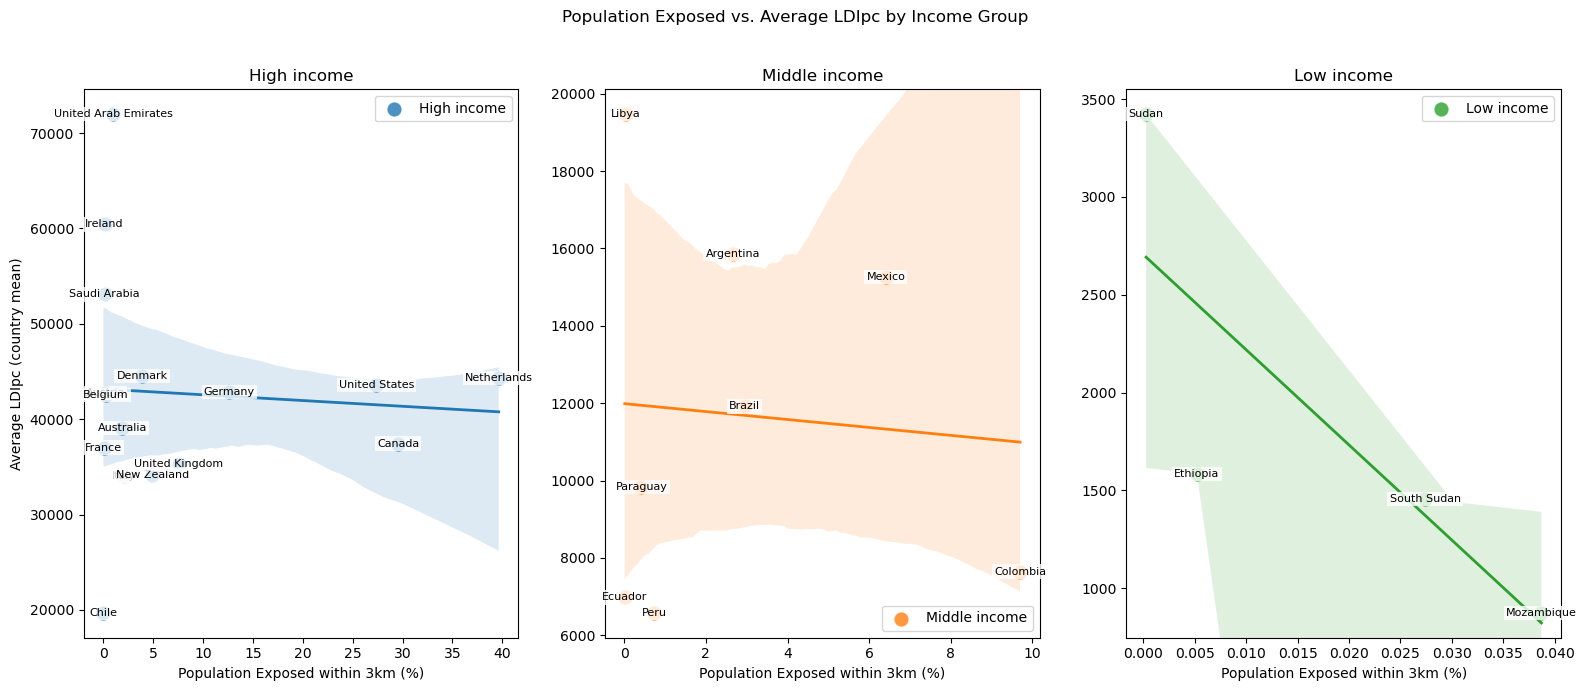

In [39]:
## Step 4: Figure 2

# Standardize country names for merging
social_data['country'] = social_data['country_location_name'].str.lower().str.replace(" ", "_")
country_exposure['country'] = country_exposure['country'].str.lower().str.replace(" ", "_")
country_exposure['exposed_1km'] = pd.to_numeric(country_exposure['exposed_1km'].astype(str).str.replace(',', ''), errors='coerce')
country_exposure['exposed_3km'] = pd.to_numeric(country_exposure['exposed_3km'].astype(str).str.replace(',', ''), errors='coerce')
country_exposure['exposed_5km'] = pd.to_numeric(country_exposure['exposed_5km'].astype(str).str.replace(',', ''), errors='coerce')

country_exposure['population'] = pd.to_numeric(country_exposure['population'].astype(str).str.replace(',', ''), errors='coerce')
country_exposure['pct_exposed_1km'] = (country_exposure['exposed_1km'] / country_exposure['population']) * 100
country_exposure['pct_exposed_3km'] = (country_exposure['exposed_3km'] / country_exposure['population']) * 100
country_exposure['pct_exposed_5km'] = (country_exposure['exposed_5km'] / country_exposure['population']) * 100

# Aggregate social data to country level (mean LDIpc_mean)
country_social = social_data.groupby('country', as_index=False)['LDIpc_mean'].mean()
country_social['country'] = country_social['country'].replace({
    'united_states_of_america': 'united_states',
    'usa': 'united_states'
})
# --- Merge exposure and social data ---
merged = country_exposure.merge(country_social, left_on='country', right_on='country', how='left')
merged = merged.merge(wbg_df, left_on='country', right_on='Economy', how='left')

# Filter out "Lower middle income"
# 1. Create a new column for combined income groups
plot_merged['Income group combined'] = plot_merged['Income group'].replace({
    'Upper middle income': 'Middle income',
    'Lower middle income': 'Middle income'
})

# 2. Define new groups and color map
income_groups = ['High income', 'Middle income', 'Low income']
palette = sns.color_palette('tab10', n_colors=len(income_groups))
color_map = dict(zip(income_groups, palette))

fig, axes = plt.subplots(1, 3, figsize=(16, 7), sharey=False)

for i, group in enumerate(income_groups):
    group_data = plot_merged[plot_merged['Income group combined'] == group]
    ax = axes[i]
    sns.scatterplot(
        data=group_data,
        x='pct_exposed_3km',
        y='LDIpc_mean',
        color=color_map[group],
        s=120,
        alpha=0.8,
        label=group,
        ax=ax
    )
    # Calculate axis limits with margin
    x_min, x_max = group_data['pct_exposed_3km'].min(), group_data['pct_exposed_3km'].max()
    y_min, y_max = group_data['LDIpc_mean'].min(), group_data['LDIpc_mean'].max()
    x_margin = (x_max - x_min) * 0.05 if x_max > x_min else 1
    y_margin = (y_max - y_min) * 0.05 if y_max > y_min else 1
    ax.set_xlim(x_min - x_margin, x_max + x_margin)
    ax.set_ylim(y_min - y_margin, y_max + y_margin)

    for _, row in group_data.iterrows():
        ax.text(
            row['pct_exposed_3km'],
            row['LDIpc_mean'],
            row['country'].replace('_', ' ').title(),
            fontsize=8,
            ha='center',
            va='center',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1.5)
        )
    if len(group_data) > 1:
        sns.regplot(
            data=group_data,
            x='pct_exposed_3km',
            y='LDIpc_mean',
            scatter=False,
            color=color_map[group],
            line_kws={'linewidth': 2},
            ax=ax
        )
    ax.set_xlabel('Population Exposed within 3km (%)')
    if i == 0:
        ax.set_ylabel('Average LDIpc (country mean)')
    else:
        ax.set_ylabel('')
    ax.set_title(f'{group}')

plt.suptitle('Population Exposed vs. Average LDIpc by Income Group')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [41]:
adm2_exposed

,ID_admin_unit,population,country,exposed_1km,exposed_3km,exposed_5km,pct_exposed_1km,pct_exposed_3km,pct_exposed_5km
0,1001009,20132,argentina,NaN,NaN,NaN,NaN,NaN,NaN
1,2001009,13483,argentina,NaN,NaN,NaN,NaN,NaN,NaN
2,3001009,12911,argentina,NaN,NaN,NaN,NaN,NaN,NaN
3,4001009,560006,argentina,NaN,NaN,NaN,NaN,NaN,NaN
4,5001009,10196,argentina,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
16875,17025239,490244,venezuela,NaN,NaN,NaN,NaN,NaN,NaN
16876,18025239,67056,venezuela,NaN,NaN,NaN,NaN,NaN,NaN
16877,19025239,47378,venezuela,NaN,NaN,NaN,NaN,NaN,NaN
16878,20025239,64976,venezuela,NaN,NaN,NaN,NaN,NaN,NaN


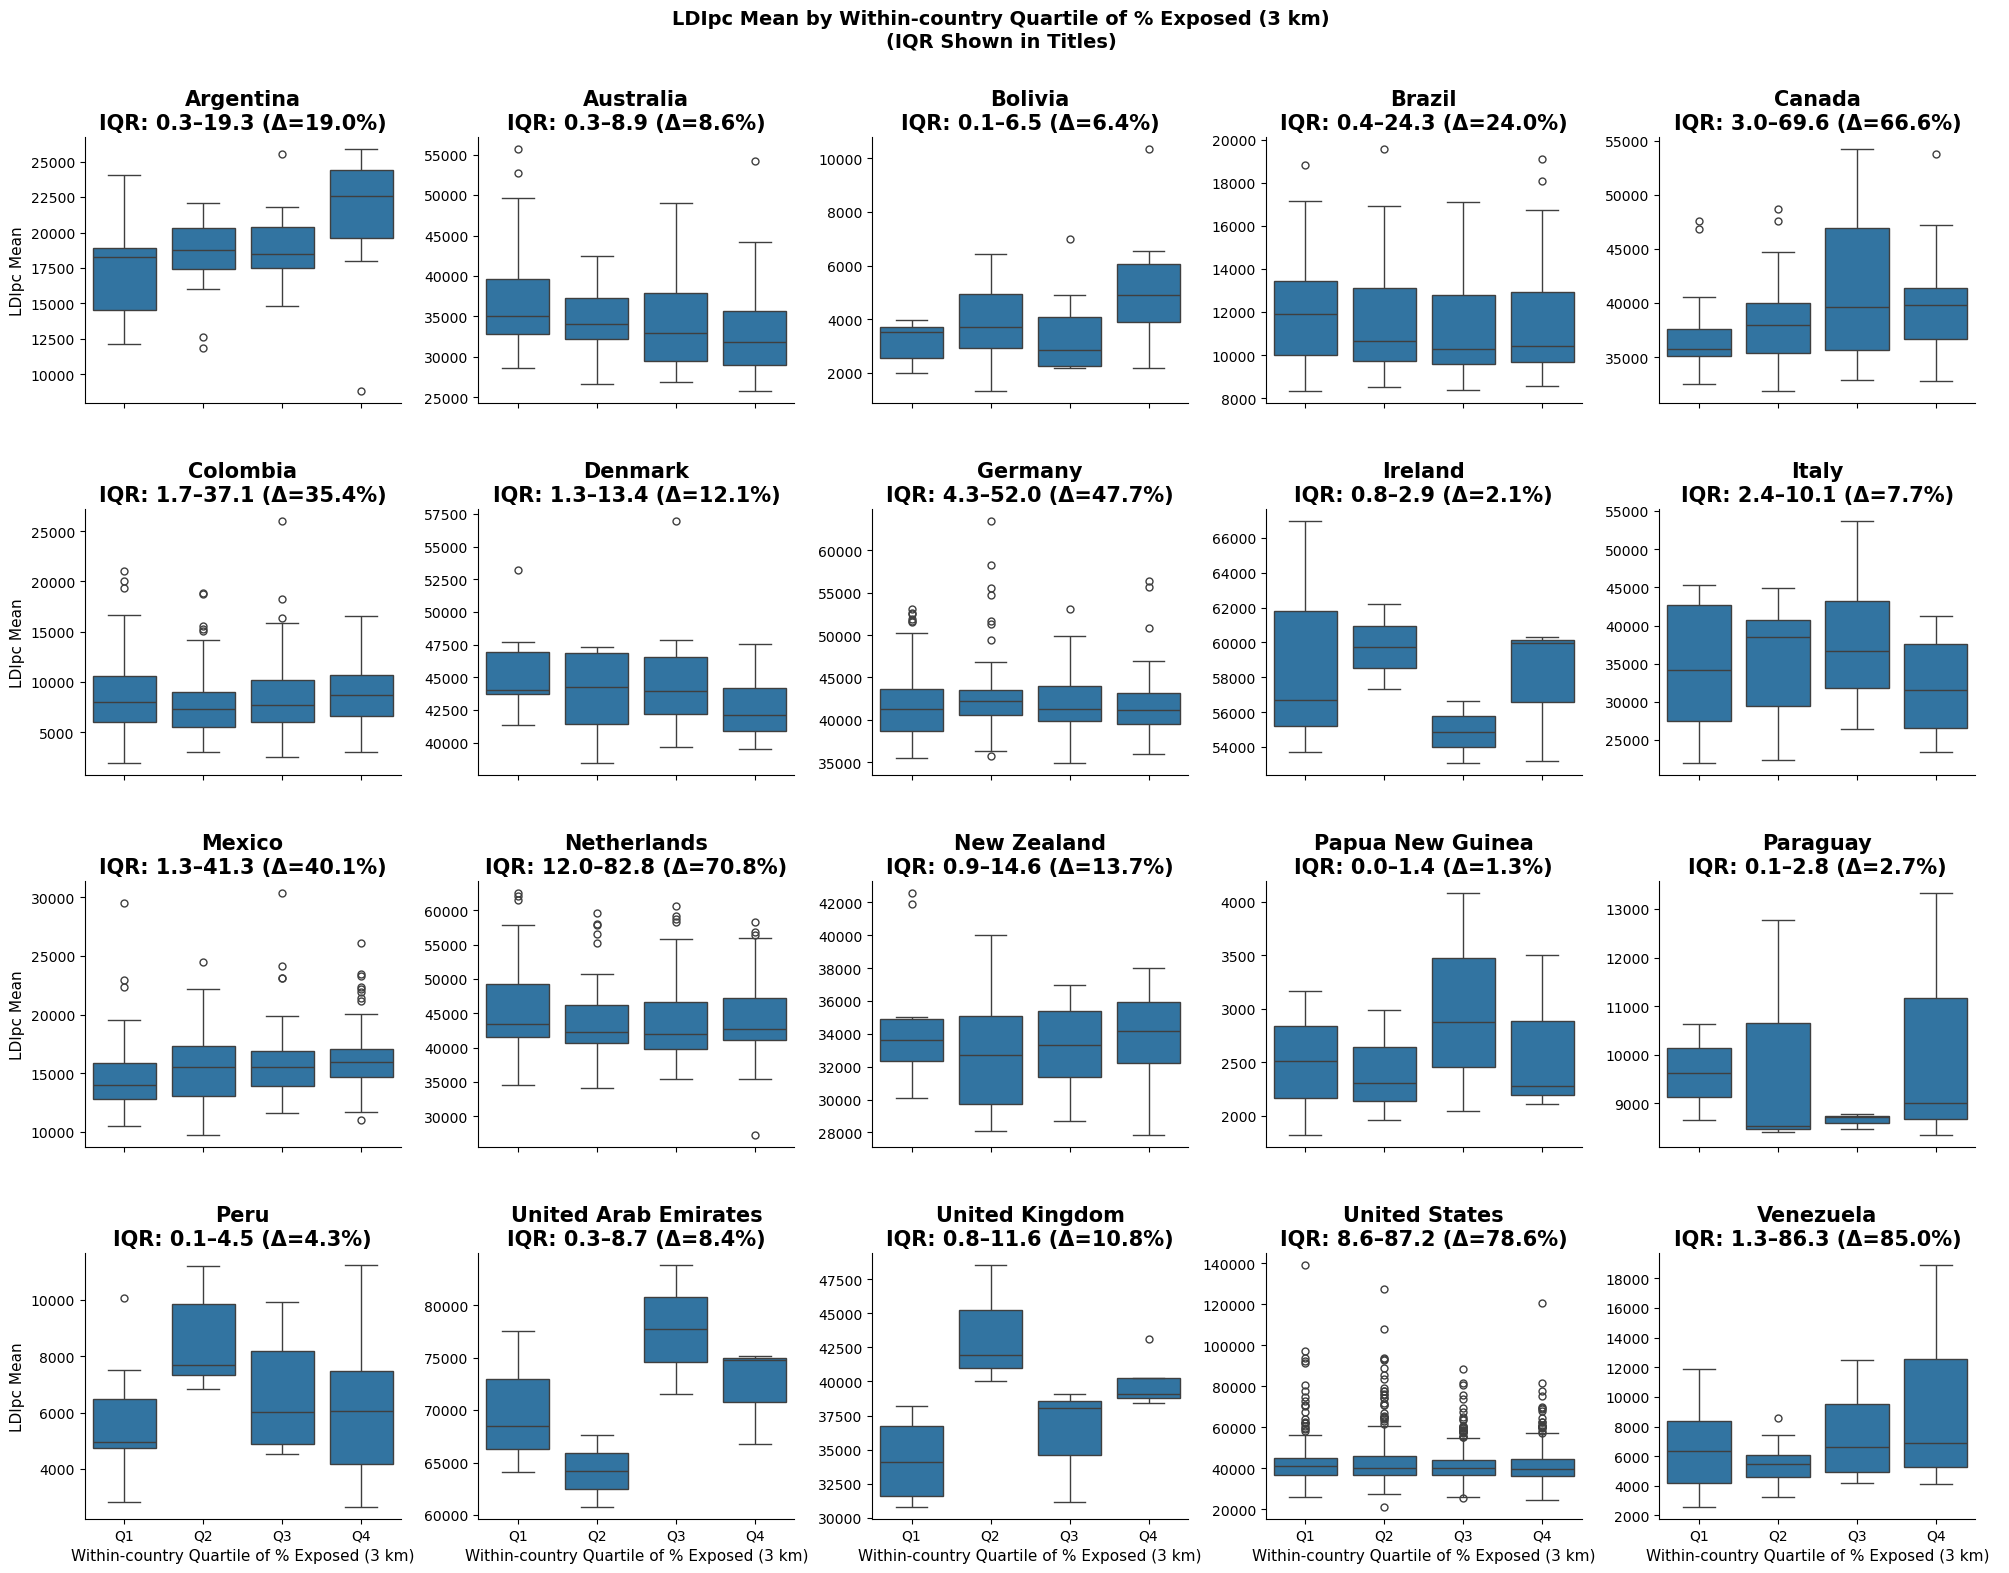

In [42]:
## Step 5: Figure 3

# Standardize country names in shapefile
merged_shapefile_social['ADM0_NAME'] = merged_shapefile_social['ADM0_NAME'].str.lower().str.replace(" ", "_")

# Merge exposure and spatial/social data
merged = adm2_exposed.merge(
    merged_shapefile_social,
    left_on=['country', 'ID_admin_unit'],
    right_on=['ADM0_NAME', 'ADM2_CODE'],
    how='left'
)

# Filter for non-zero, non-null exposure
merged_nonzero = merged[(merged['pct_exposed_3km'] > 0) & merged['pct_exposed_3km'].notna()].copy()

# ✅ Convert proportion to percent
merged_nonzero['pct_exposed_3km_percent'] = merged_nonzero['pct_exposed_3km'] * 100

# Bin into 5% intervals (0–5%, 5–10%, ..., up to 100%)
merged_nonzero['pct_exposed_3km_bin'] = pd.cut(
    merged_nonzero['pct_exposed_3km_percent'],
    bins=range(0, 105, 5),
    labels=[f"{i}-{i+5}%" for i in range(0, 100, 5)],
    right=False
)

# Drop rows outside bin range
merged_nonzero = merged_nonzero[merged_nonzero['pct_exposed_3km_bin'].notna()]

#  WBG income classification
wbg_df['Economy'] = wbg_df['Economy'].str.lower().str.replace(" ", "_")

# Merge classification into main DataFrame
merged_nonzero = merged_nonzero.merge(
    wbg_df,
    left_on='ADM0_NAME',
    right_on='Economy',
    how='left'
)

# --- Clean data as before ---
merged_nonzero = merged_nonzero[merged_nonzero['pct_exposed_3km'] > 0].copy()
merged_nonzero = merged_nonzero[merged_nonzero['pct_exposed_3km'].notna()]

countries_to_remove = [
    "austria", "belgium", "chile", "ecuador", "ethiopia", "france", 
    "libya", "mozambique", "saudi_arabia", "south_sudan", "sudan"
]
merged_nonzero = merged_nonzero[~merged_nonzero['country'].str.lower().isin(countries_to_remove)]

# --- Quartile function ---
def assign_quartiles(x):
    try:
        q, bins = pd.qcut(x, 4, labels=['Q1', 'Q2', 'Q3', 'Q4'], retbins=True, duplicates='drop')
        n_bins = len(bins) - 1
        if n_bins < 4:
            labels = [f"Q{i+1}" for i in range(n_bins)]
            q = pd.qcut(x, n_bins, labels=labels, duplicates='drop')
        return q
    except ValueError:
        return pd.Series([pd.NA]*len(x), index=x.index)

merged_nonzero['pct_exposed_3km_quartile_country'] = (
    merged_nonzero.groupby('country')['pct_exposed_3km'].transform(assign_quartiles)
)

# --- Calculate IQR ---
iqr_df = merged_nonzero.groupby('country')['pct_exposed_3km'].quantile([0.25, 0.75]).unstack()
iqr_df.columns = ['Q1', 'Q3']
iqr_df['IQR'] = iqr_df['Q3'] - iqr_df['Q1']

def make_iqr_title(country):
    country_name = country.replace('_', ' ').title()
    if country in iqr_df.index:
        # multiply values by 100 for percentage
        q1 = iqr_df.loc[country, 'Q1'] * 100
        q3 = iqr_df.loc[country, 'Q3'] * 100
        iqr = iqr_df.loc[country, 'IQR'] * 100
        return f"{country_name}\nIQR: {q1:.1f}–{q3:.1f} (Δ={iqr:.1f}%)"
    else:
        return country_name

# --- Plot ---
g = sns.catplot(
    data=merged_nonzero,
    x='pct_exposed_3km_quartile_country',
    y='LDIpc_mean',
    col='country',
    kind='box',
    col_wrap=5,
    height=4,
    sharey=False
)

# Set custom titles with country bolded, IQR normal weight
for ax, country in zip(g.axes.flat, g.col_names):
    ax.set_title(make_iqr_title(country), fontsize=15, fontweight='bold')

# Increase axis label sizes
g.set_axis_labels('Within-country Quartile of % Exposed (3 km)', 'LDIpc Mean', fontsize=11)

# Adjust spacing between rows to avoid overlap of x-axis labels
g.fig.subplots_adjust(hspace=0.4, top=0.9)  # hspace adds vertical spacing

# Supertitle
g.fig.suptitle('LDIpc Mean by Within-country Quartile of % Exposed (3 km)\n(IQR Shown in Titles)',
               fontsize=14, fontweight='bold')
plt.show()

### the countries above were removed bc of small numbers? or something else? would just add it in the comment

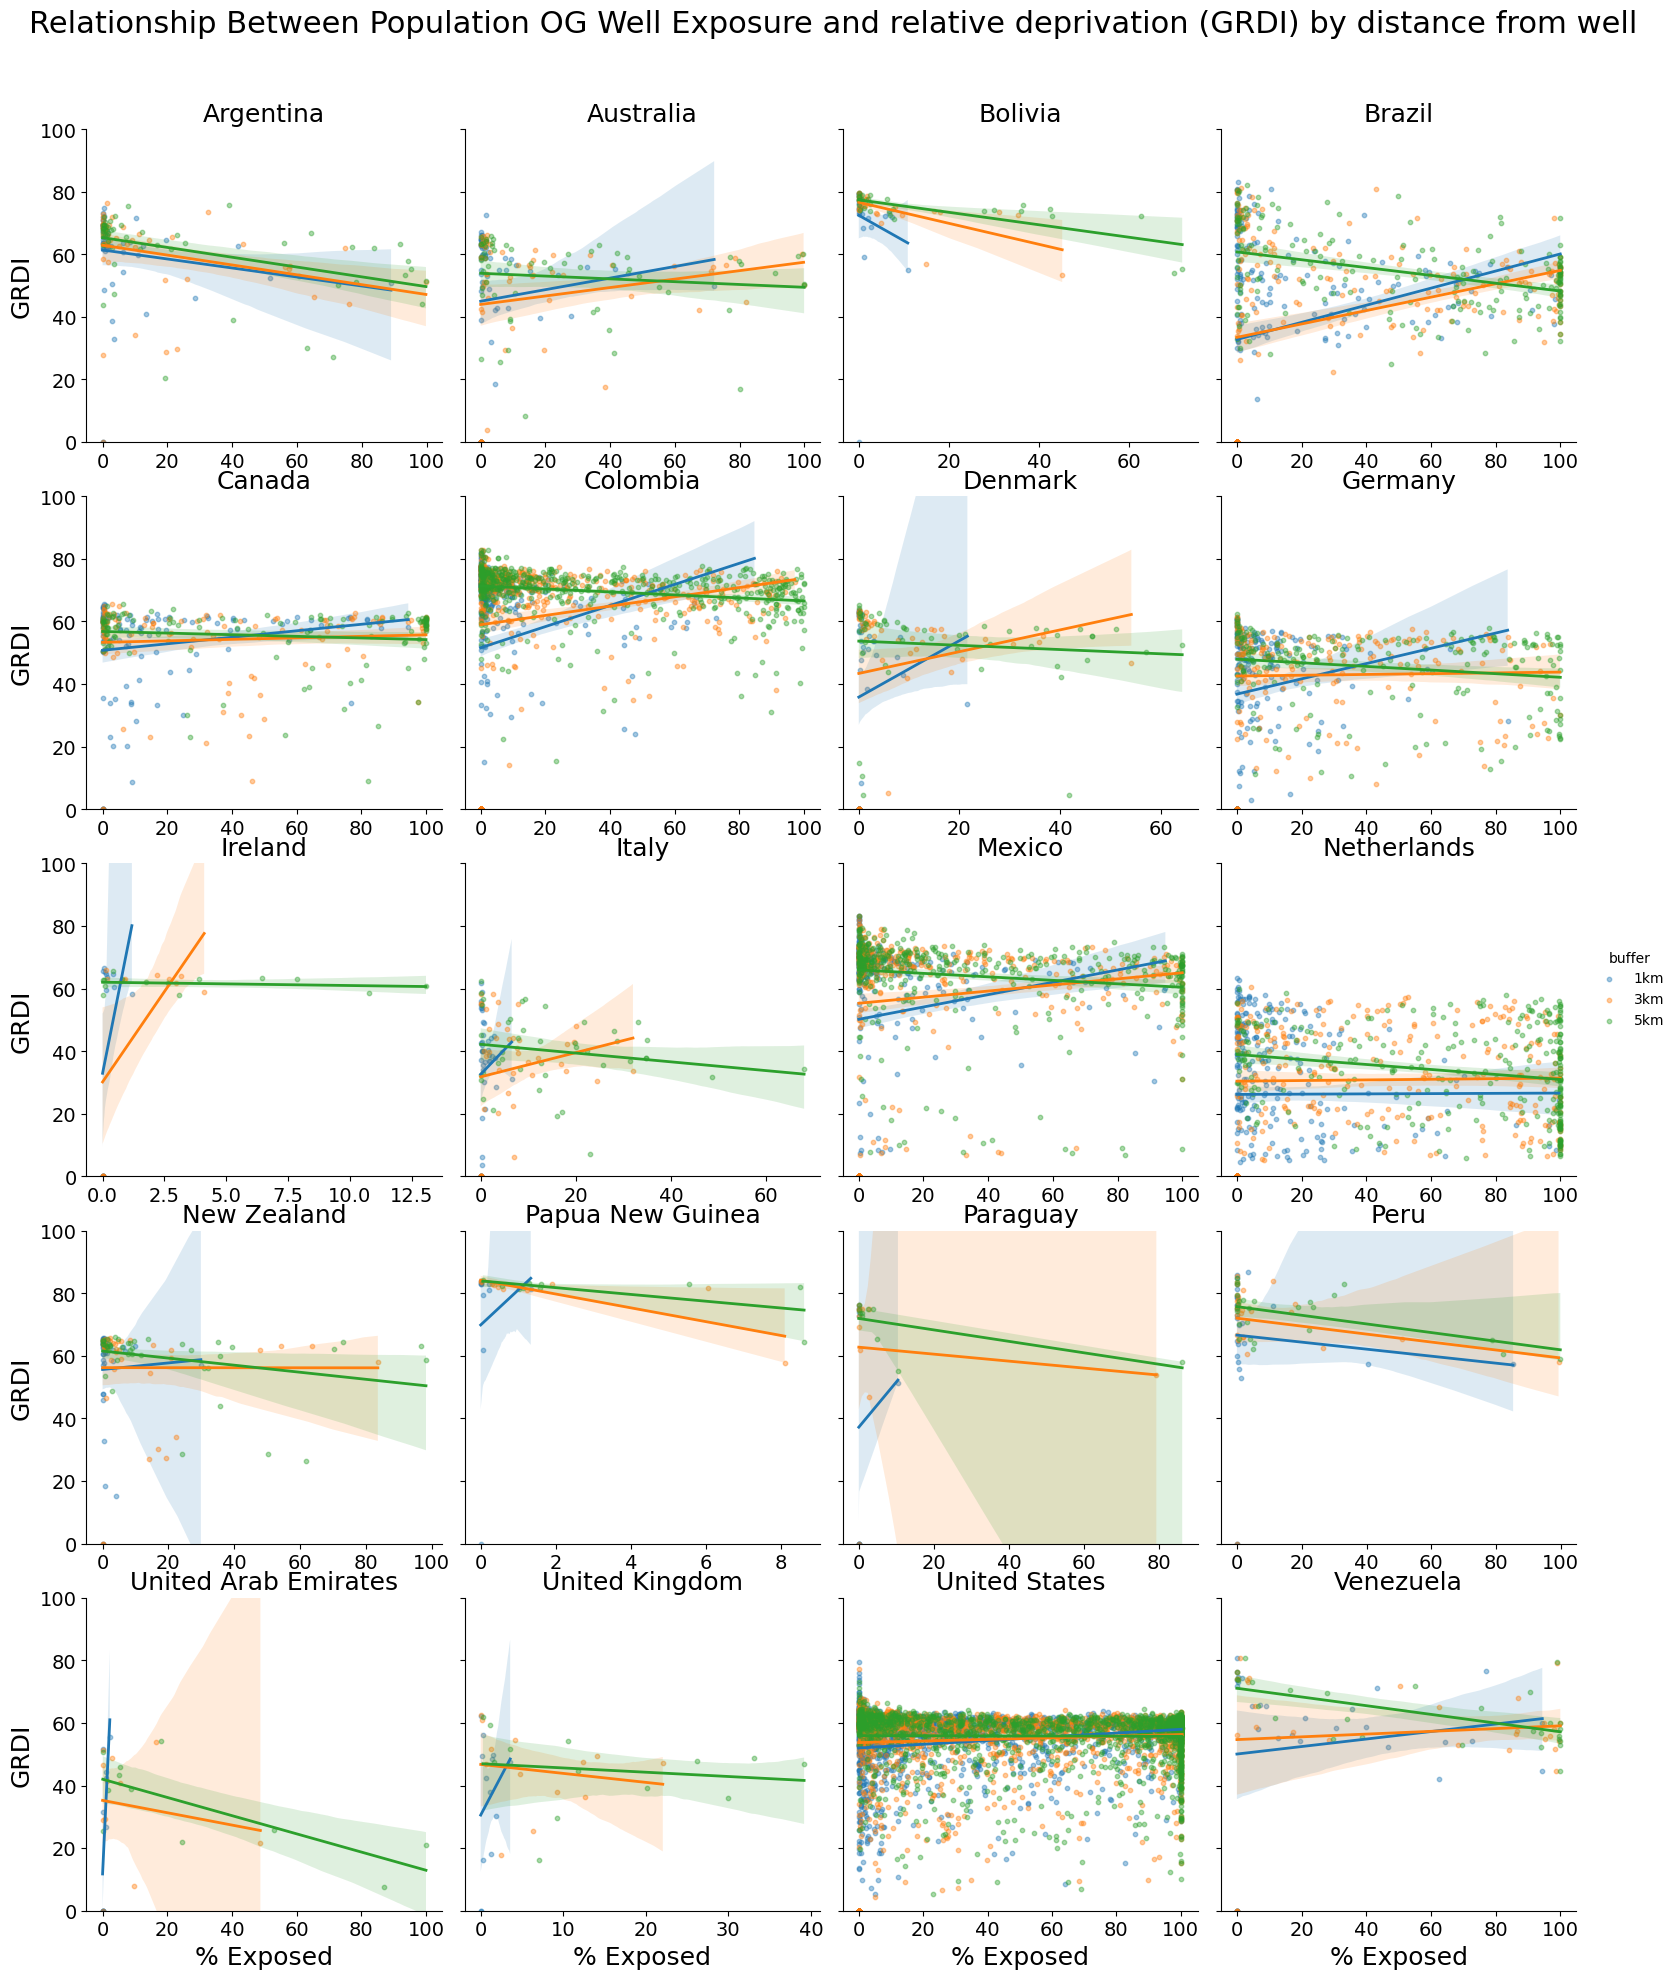

In [58]:
## Step 6: Figure 4

# Merge GRDI with exposure
merged = GRDI_data.merge(
    adm2_exposed,
    left_on=['country', 'ID_admin_unit'],
    right_on=['country', 'ID_admin_unit'],
    how='inner'
)

# ── Merge with ADM2 spatial/social data ────────
merged_shapefile_social['ADM0_NAME'] = (
    merged_shapefile_social['ADM0_NAME'].str.lower().str.replace(" ", "_")
)

merged = merged.merge(
    merged_shapefile_social,
    left_on=['country', 'ID_admin_unit'],
    right_on=['ADM0_NAME', 'ADM2_CODE'],
    how='left'
)

# ── Keep only valid data ───────────────────────
merged = merged[(merged['pct_exposed_1km'].notna()) & (merged['GRDI_1km'].notna())].copy()

#  Convert to percent
merged['pct_exposed_1km_percent'] = merged['pct_exposed_1km'] * 100
merged['GRDI_1km_percent'] = merged['GRDI_1km'] * 100

merged['pct_exposed_3km_percent'] = merged['pct_exposed_3km'] * 100
merged['GRDI_3km_percent'] = merged['GRDI_3km'] * 100

merged['pct_exposed_5km_percent'] = merged['pct_exposed_5km'] * 100
merged['GRDI_5km_percent'] = merged['GRDI_5km'] * 100

# Merge classification
merged = merged.merge(
    wbg_df,
    left_on='ADM0_NAME',
    right_on='Economy',
    how='left'
)


# Filter for valid data and GRDI bounds
plot_df = merged[
    (merged['pct_exposed_3km_percent'].notna()) &
    (merged['GRDI_3km'].notna()) &
    (merged['pct_exposed_1km_percent'].notna()) &
    (merged['GRDI_1km'].notna()) &
    (merged['GRDI_3km'].between(0, 100)) &
    (merged['GRDI_1km'].between(0, 100))
].copy()

# Optional: subset to countries with enough data points
min_obs = 10
country_counts = plot_df['country'].value_counts()
valid_countries = country_counts[country_counts >= min_obs].index
plot_df = plot_df[plot_df['country'].isin(valid_countries)]

# Format country names for titles
plot_df['country_label'] = plot_df['country'].str.replace('_', ' ').str.title()

# Reshape data from wide to long format for 1km, 3km, 5km
long_df = pd.concat([
    plot_df[['country_label', 'pct_exposed_1km_percent', 'GRDI_1km']].rename(
        columns={'pct_exposed_1km_percent': 'pct_exposed', 'GRDI_1km': 'GRDI'}
    ).assign(buffer='1km'),
    plot_df[['country_label', 'pct_exposed_3km_percent', 'GRDI_3km']].rename(
        columns={'pct_exposed_3km_percent': 'pct_exposed', 'GRDI_3km': 'GRDI'}
    ).assign(buffer='3km'),
    plot_df[['country_label', 'pct_exposed_5km_percent', 'GRDI_5km']].rename(
        columns={'pct_exposed_5km_percent': 'pct_exposed', 'GRDI_5km': 'GRDI'}
    ).assign(buffer='5km')
])

# Faceted scatter plot with regression lines for all three buffers
g = sns.lmplot(
    data=long_df,
    x='pct_exposed',
    y='GRDI',
    hue='buffer',
    col='country_label',
    col_wrap=4,
    height=4,
    scatter_kws={'alpha': 0.4, 's': 10},  
    line_kws={'linewidth': 2},
    facet_kws={'sharex': False, 'sharey': True}
)

# Make all labels bigger
g.set_axis_labels('% Exposed', 'GRDI', fontsize=18)
g.set_titles('{col_name}', size=18)
plt.subplots_adjust(top=0.92)
g.fig.suptitle('Relationship Between Population OG Well Exposure and relative deprivation (GRDI) by distance from well', fontsize=22)
plt.ylim(0, 100)

# Make tick labels bigger for all axes
for ax in g.axes.flat:
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.xaxis.label.set_size(18)
    ax.yaxis.label.set_size(18)

plt.show()
